In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from mpl_chord_diagram import chord_diagram

In [9]:
test = np.load(
    r"C:\Users\lain\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\afolu_resources\generated\transition_cube.npy"
)

In [57]:
df = pd.read_csv(
    r"C:\Users\lain\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\afolu_resources\generated\transition_cross_fixed\2000_2001.csv"
).set_index("start")

zero_rows = df.index[df.sum(axis=1) == 0]

df = df.drop(index=zero_rows, columns=zero_rows)

nonzero_labels = [label for label in LABEL_LIST if label not in zero_rows]

pretty_labels = []
for label in nonzero_labels:
    parts = label.split("_")
    if len(parts) == 1:
        pretty_labels.append(label.title())
    else:
        pretty_labels.append(f"{parts[0].title()}\n({parts[1].title()})")

In [58]:
flow = np.zeros((len(nonzero_labels), len(nonzero_labels)))

for i, first_label in enumerate(nonzero_labels):
    for j, second_label in enumerate(nonzero_labels):
        if i != j:
            first_to_second = df.loc[first_label, second_label]
            second_to_first = df.loc[second_label, first_label]
            if first_to_second > second_to_first:
                flow[i, j] = first_to_second - second_to_first
            else:
                flow[j, i] = second_to_first - first_to_second

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\mpl_chord_diagram\utilities.py:167: RuntimeWarning:

invalid value encountered in divide



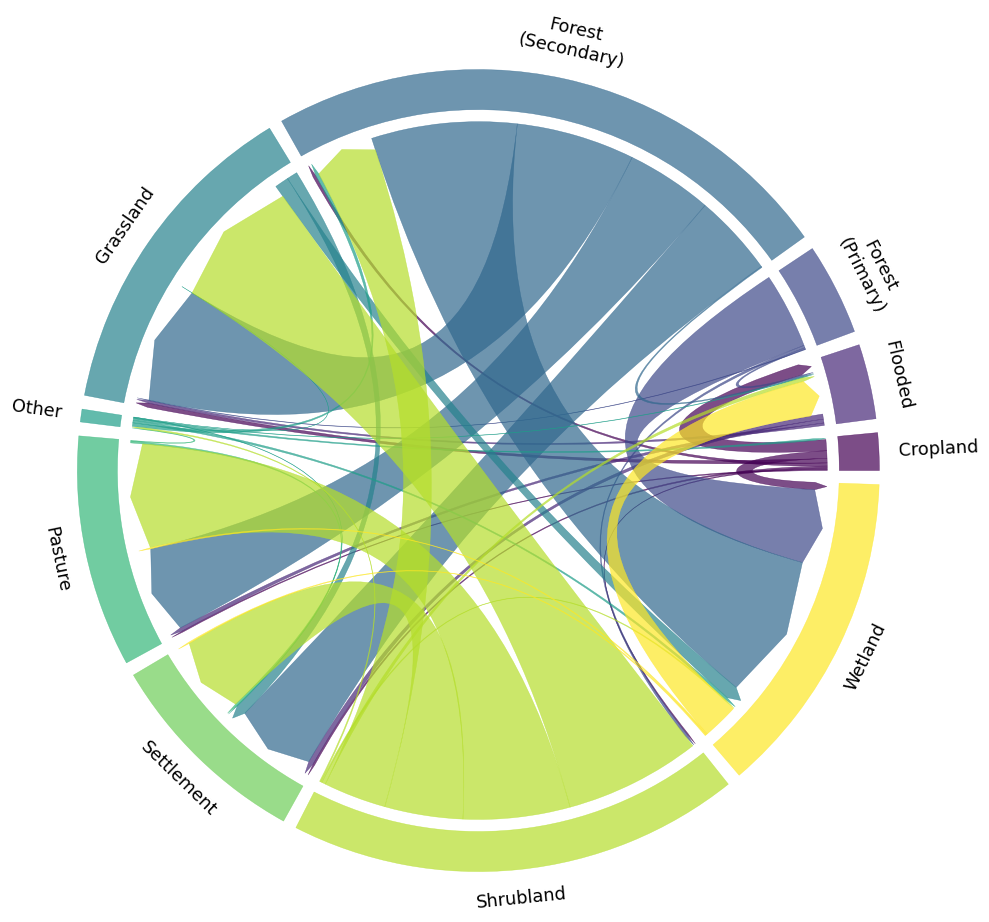

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))
_ = chord_diagram(
    flow,
    directed=True,
    names=pretty_labels,
    ax=ax,
    rotate_names=[True, False, False, False, False, True, False, False, False, False],
    sort="size",
)
fig.savefig("./figures/1.jpg", bbox_inches="tight", dpi=200)

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\mpl_chord_diagram\utilities.py:167: RuntimeWarning:

invalid value encountered in divide



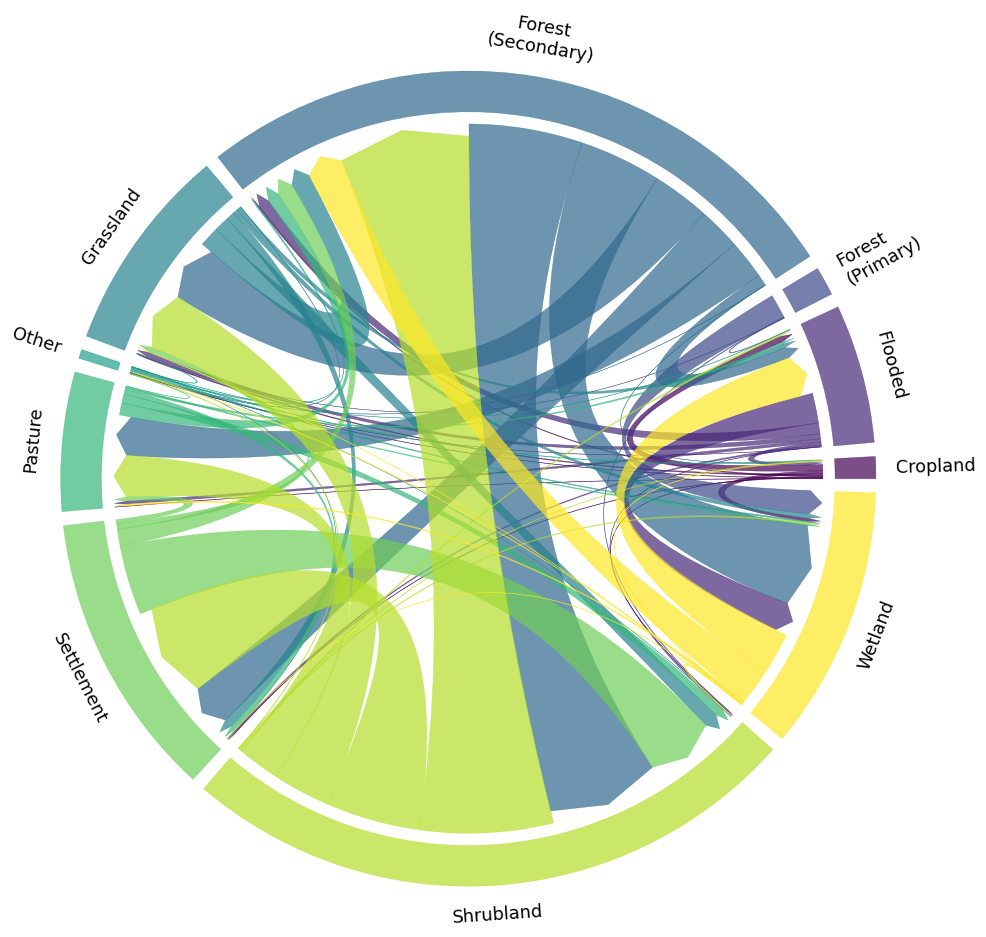

In [76]:
test = df.to_numpy(copy=True)
np.fill_diagonal(test, 0)

fig, ax = plt.subplots(figsize=(10, 10))
_ = chord_diagram(
    test,
    directed=True,
    names=pretty_labels,
    rotate_names=[True, False, True, False, False, True, False, False, False, False],
    ax=ax,
)
fig.savefig("./figures/2.jpg", bbox_inches="tight", dpi=200)

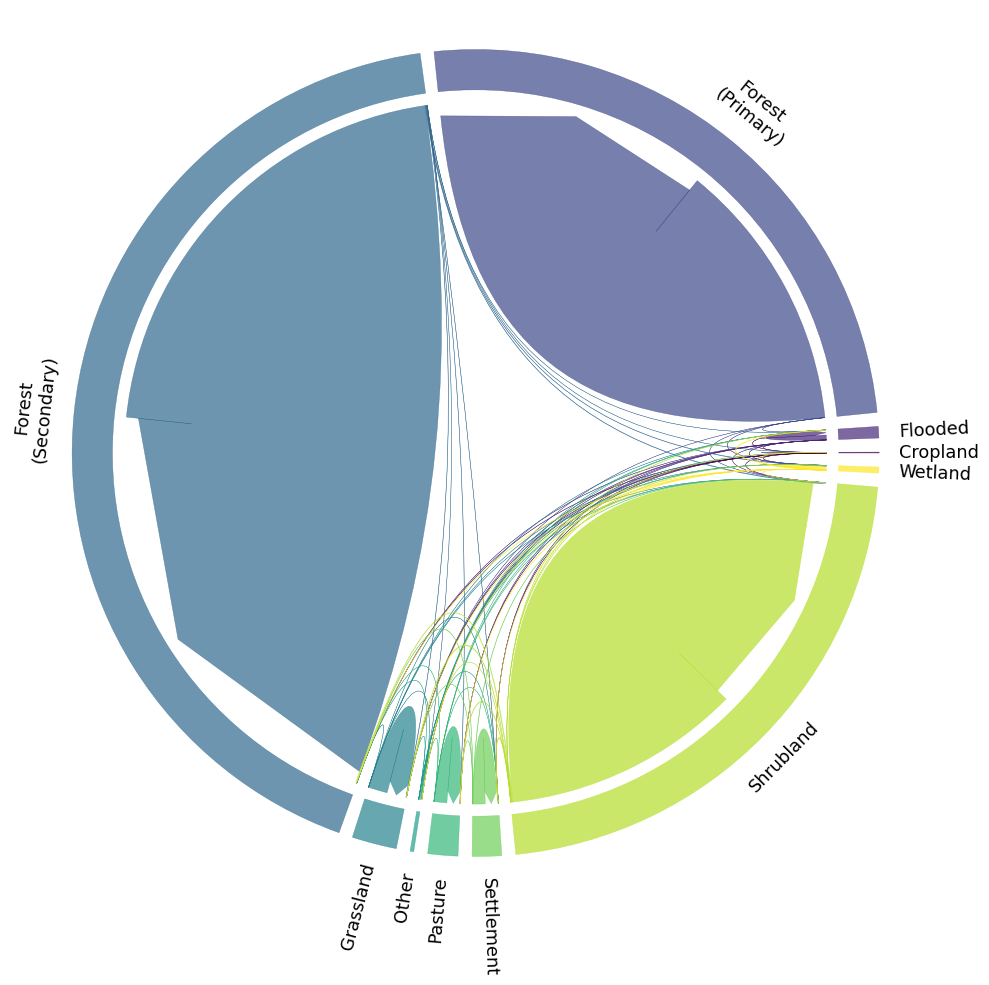

In [77]:
test = df.to_numpy(copy=True)

fig, ax = plt.subplots(figsize=(10, 10))
_ = chord_diagram(
    test,
    directed=True,
    names=pretty_labels,
    rotate_names=[True, True, False, False, True, True, True, True, False, True],
    ax=ax,
)
fig.savefig("./figures/3.jpg", bbox_inches="tight", dpi=200)